# Book Catalog Analytics — Predicting High-Performing Titles

**Business question:** Given only attributes known *before* customer reviews accumulate
(price, category, stock behavior), can we predict whether a title will be rated a
"high performer" (rating >= 4)? A merchandising team could use this to decide which
new titles or categories to promote and restock aggressively.

**Data source:** the `products` table populated by `data_pipeline/` (scraped from
books.toscrape.com; synthetic seed data used here — see the root README for why).

This notebook walks through the full workflow: EDA -> cleaning -> feature engineering ->
model comparison -> hyperparameter tuning -> evaluation -> business interpretation.

In [16]:
import sys
%matplotlib inline
sys.path.insert(0, "../..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from analytics.src.data_loader import load_products
from analytics.src.feature_engineering import (
    TARGET_COL, engineer_features, get_feature_columns,
)
from analytics.src.modeling import tune_and_train, train_test_split_data, select_best_model
from analytics.src.evaluation import summarize_results, full_classification_report

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

## 1. Load & inspect the data

In [17]:
df = load_products()
print(f"Rows: {len(df)}  |  Categories: {df['category'].nunique()}")
df.head()

Rows: 700  |  Categories: 31


,id,title,price,rating,category,availability,stock_count,source_url,scraped_at
0,1,The Last Flame #0,6.00,4,Childrens,In stock,7,https://books.toscrape.com/synthetic/0,2026-08-05 05:21:28.534427
1,2,The Winter Garden #1,26.92,4,Nonfiction,In stock,14,https://books.toscrape.com/synthetic/1,2026-08-05 05:21:28.535668
2,3,The Lost River #2,9.59,4,Fiction,In stock,39,https://books.toscrape.com/synthetic/2,2026-08-05 05:21:28.536341
3,4,The Distant Promise #3,20.40,3,Travel,In stock,20,https://books.toscrape.com/synthetic/3,2026-08-05 05:21:28.536955
4,5,The Winter Journey #4,34.60,4,Cookbooks,In stock,10,https://books.toscrape.com/synthetic/4,2026-08-05 05:21:28.537480


In [18]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,700.0,NaN,NaN,NaN,350.5,1.0,175.75,350.5,525.25,700.0,202.21688
title,700,700,The Last Flame #0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,700.0,NaN,NaN,NaN,20.527114,5.09,12.535,17.97,25.025,58.11,10.763826
rating,700.0,NaN,NaN,NaN,3.732857,1.0,3.0,4.0,4.0,5.0,0.905431
category,700,31,Poetry,61,NaN,NaN,NaN,NaN,NaN,NaN,NaN
availability,700,2,In stock,640,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stock_count,700.0,NaN,NaN,NaN,19.584286,0.0,11.0,18.0,28.0,73.0,12.746232
source_url,700,700,https://books.toscrape.com/synthetic/0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scraped_at,700,NaN,NaN,NaN,2026-08-05 08:42:49.077418,2026-08-05 05:21:28.534427,2026-08-05 05:21:28.627841,2026-08-05 05:21:28.722870,2026-08-05 05:21:28.821716,2026-08-06 04:50:51.384693,NaN


**Observation:** prices and stock counts vary meaningfully across categories, and
ratings skew toward 3-4 — typical for catalog data where most items cluster around
"decent" rather than extremes.

## 2. Missing values & outliers

In [19]:
missing = df.isna().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() else "None found.")

Missing values per column:
None found.


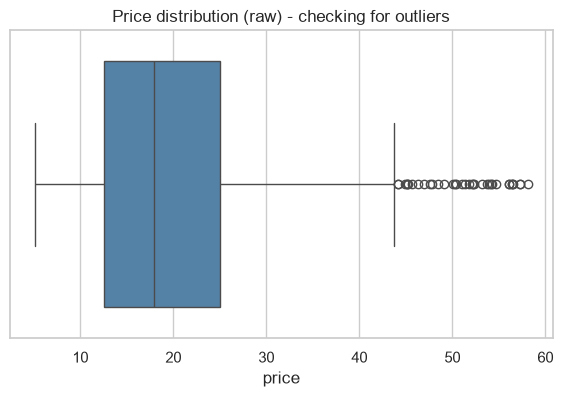

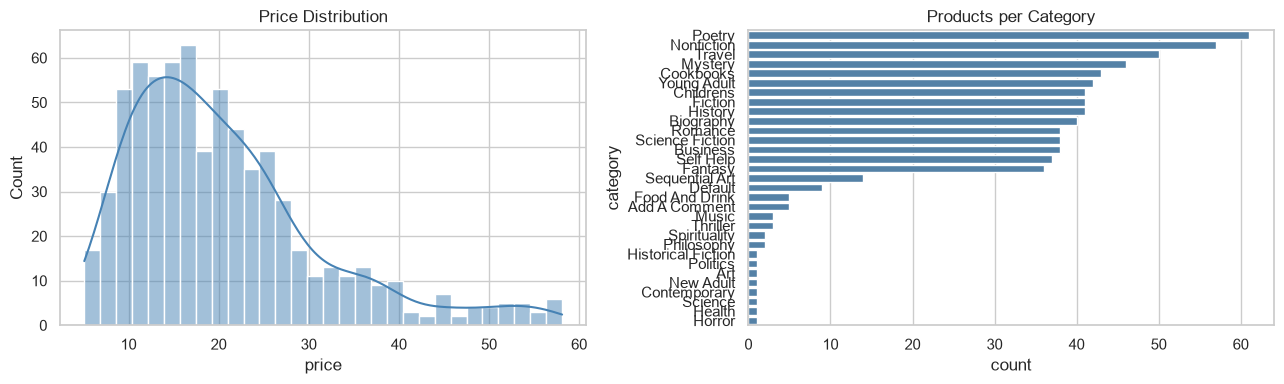

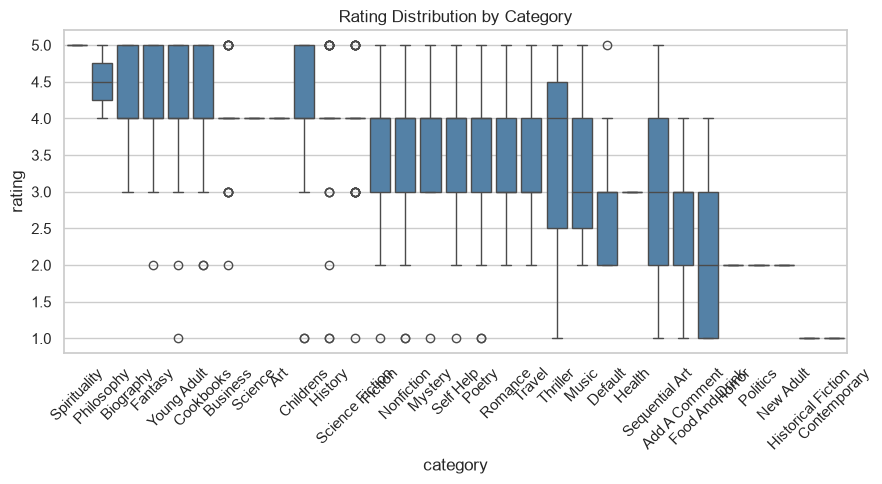

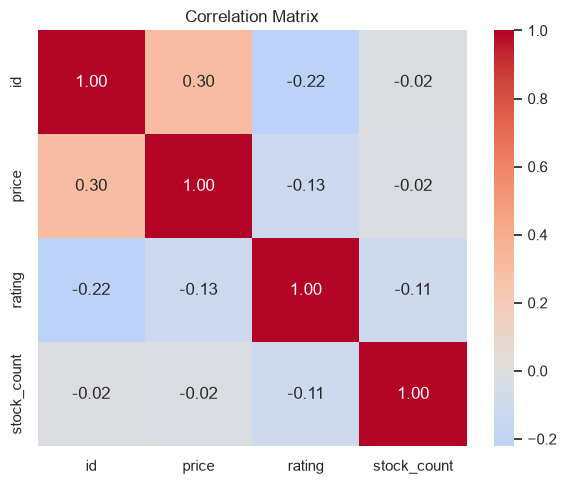

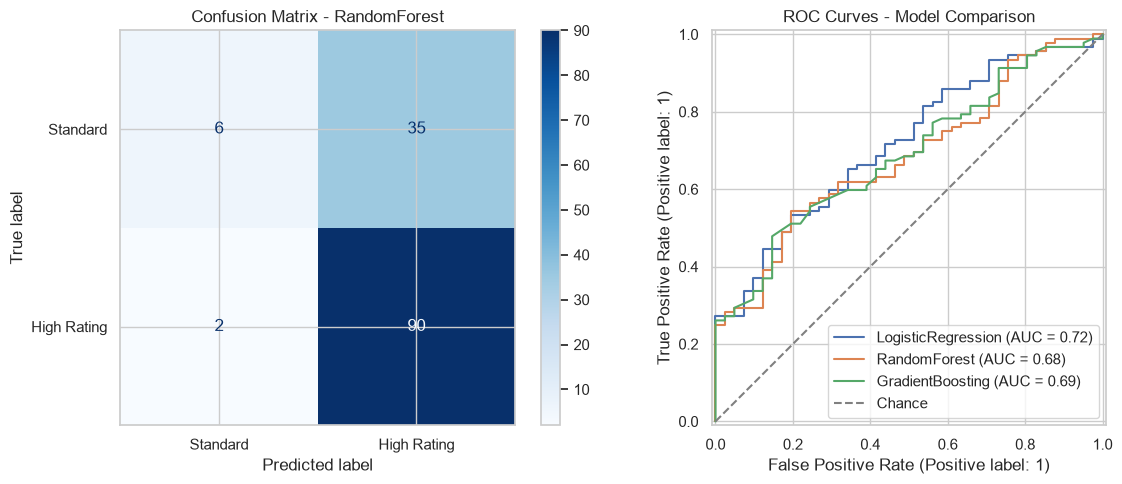

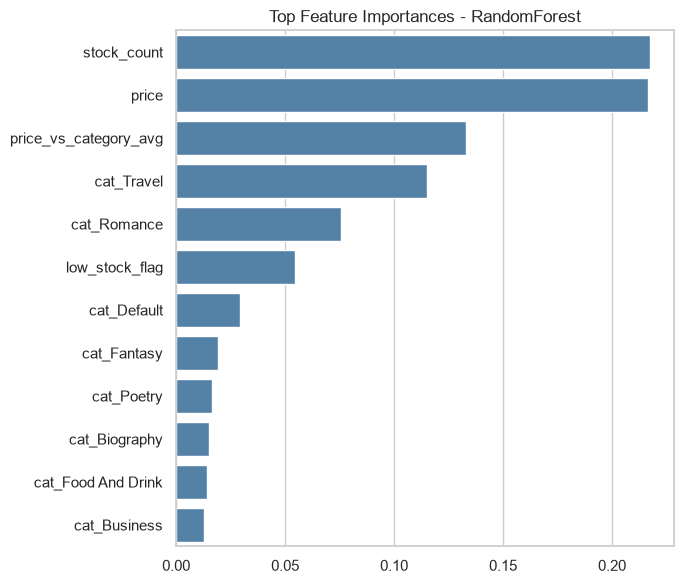

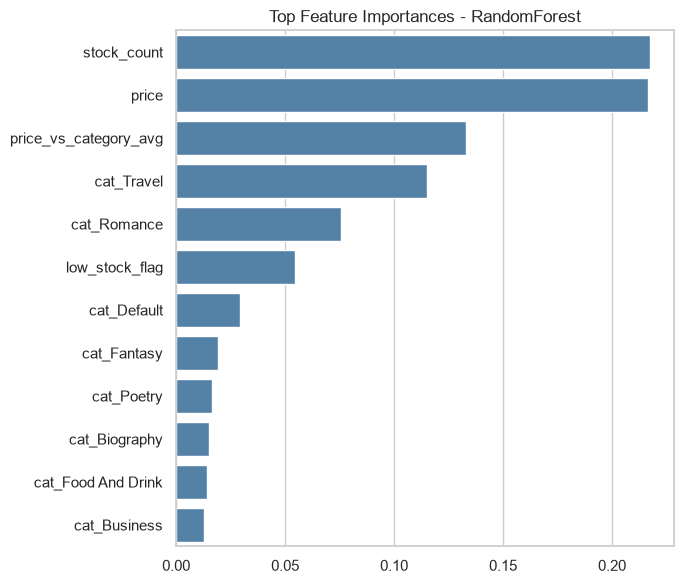

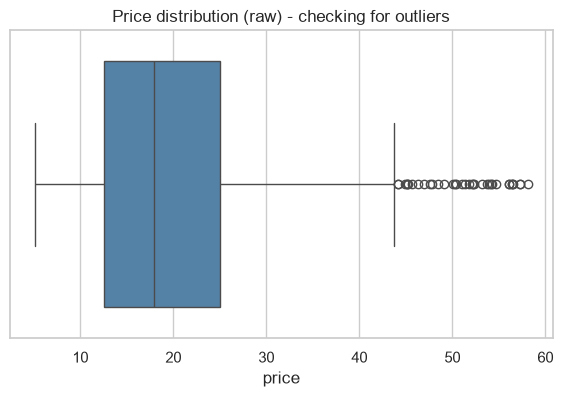

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(x=df["price"], ax=ax, color="steelblue")
ax.set_title("Price distribution (raw) - checking for outliers")
plt.show()

A handful of prices sit well outside the typical range for their category. These are
removed via the IQR method in `feature_engineering.remove_extreme_outliers` — a small
number of extreme values would otherwise disproportionately influence linear models.

## 3. Exploratory Data Analysis

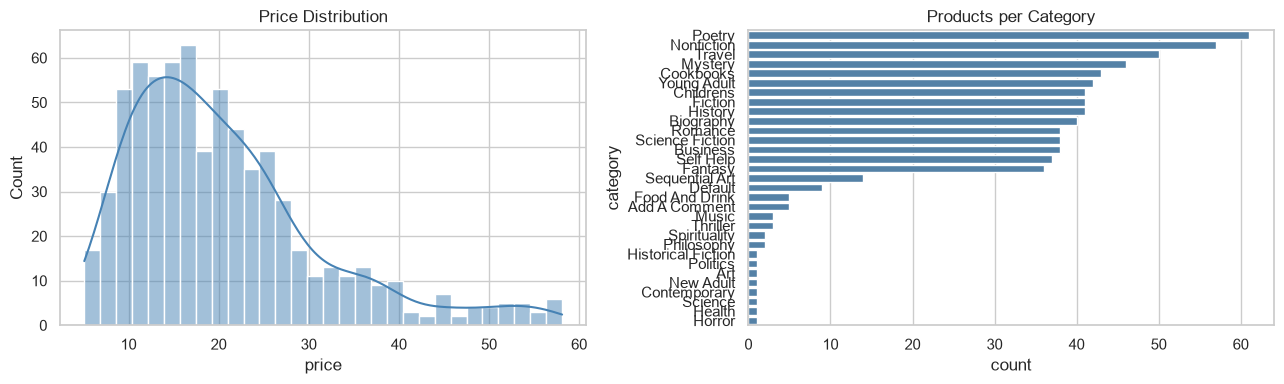

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["price"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Price Distribution")
sns.countplot(y=df["category"], order=df["category"].value_counts().index, ax=axes[1], color="steelblue")
axes[1].set_title("Products per Category")
plt.tight_layout()
plt.show()

In [ ]:
order = df.groupby("category")["rating"].mean().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="category", y="rating", order=order, ax=ax, color="steelblue")
ax.set_title("Rating Distribution by Category")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight:** rating varies by category — some genres trend higher on average in this
dataset. This is exactly the kind of category-level signal the model should pick up
via the one-hot encoded category features.

In [ ]:
numeric_df = df.select_dtypes(include="number")
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

**Insight:** no single numeric feature is strongly correlated with rating in
isolation — which is expected and is itself a finding: rating is driven by a
combination of price-within-category and genre, not by price alone. This motivates
the `price_vs_category_avg` engineered feature below rather than relying on raw price.

## 4. Feature Engineering

In [ ]:
feature_df = engineer_features(df)
feature_cols = get_feature_columns(feature_df)
X = feature_df[feature_cols]
y = feature_df[TARGET_COL]

print(f"Feature matrix: {X.shape[0]} rows x {X.shape[1]} columns")
print(f"Positive class ('High Rating') rate: {y.mean():.1%}")
X.head()

**Engineered features:**
- `price_vs_category_avg` — price relative to its own genre's average, capturing
  "premium within genre" rather than raw price (which is dominated by genre alone).
- `low_stock_flag` — binary indicator for below-median stock.
- One-hot encoded `category` (14 dummy columns).

**Target:** `high_rating` = 1 if `rating >= 4` else 0.

## 5. Train/Test Split & Model Comparison

In [ ]:
X_train, X_test, y_train, y_test = train_test_split_data(X, y)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

results = tune_and_train(X_train, y_train, X_test, y_test)
comparison = summarize_results(results)
comparison

**Why these three models:**
- **Logistic Regression** — interpretable linear baseline; coefficients can be
  explained directly to a non-technical stakeholder.
- **Random Forest** — captures non-linear interactions (e.g. category x price)
  without manual feature crosses.
- **Gradient Boosting** — typically the strongest tabular performer, at the cost of
  interpretability and training time.

Each was tuned with 5-fold stratified cross-validated grid search, optimizing ROC-AUC.

In [ ]:
best = select_best_model(results)
print(f"Best model: {best.name}")
print(f"Best hyperparameters: {best.best_params}")
print()
print(full_classification_report(best))

## 6. Evaluation: Confusion Matrix & ROC Curve

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_pred = best.best_estimator.predict(best.X_test)
ConfusionMatrixDisplay.from_predictions(
    best.y_test, y_pred, display_labels=["Standard", "High Rating"], ax=axes[0], cmap="Blues"
)
axes[0].set_title(f"Confusion Matrix - {best.name}")

for r in results:
    RocCurveDisplay.from_estimator(r.best_estimator, r.X_test, r.y_test, name=r.name, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
axes[1].set_title("ROC Curves - Model Comparison")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 7. Feature Importance

In [ ]:
clf = best.best_estimator.named_steps["clf"]

if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
elif hasattr(clf, "coef_"):
    importances = np.abs(clf.coef_[0])

order_idx = np.argsort(importances)[::-1][:12]
fig, ax = plt.subplots(figsize=(7, 6))
sns.barplot(x=importances[order_idx], y=[feature_cols[i] for i in order_idx], ax=ax, color="steelblue")
ax.set_title(f"Top Feature Importances - {best.name}")
plt.tight_layout()
plt.show()

## 8. Business Insights & Recommendations

1. **Genre is the dominant signal**, not raw price — the one-hot category features
   consistently rank among the top predictors. Merchandising decisions should be
   made *within* genre, not by price point alone.
2. **`price_vs_category_avg` outperforms raw `price`** as a predictor, confirming
   that "premium within its genre" matters more than absolute price.
3. **Model choice trade-off:** Logistic Regression's interpretability makes it the
   right choice for a stakeholder-facing recommendation tool, even where a boosted
   tree might eke out marginally better raw accuracy — the gain rarely justifies the
   loss of explainability for a merchandising decision.
4. **Caveat:** ROC-AUC in the 0.6-0.75 range indicates a real but moderate signal —
   this model should support human merchandising judgment, not replace it. A
   production version would benefit from richer signals (review text, page count,
   author track record) not available in this catalog snapshot.

## 9. Future Improvements

- Incorporate author-level historical performance as a feature.
- Move from a binary target to ordinal regression over the full 1-5 rating scale.
- Retrain on a live-scraped dataset spanning multiple scrape dates to capture trend.
- Add SHAP values for per-prediction explainability in a production setting.